# Phase 2 — The Role Graph

**Virtual Role-Graph Embedding for Structural Identity**

This notebook builds and studies the **virtual graph** — the heart of the project.

**Plain idea.** A normal graph connects nodes that are physically linked. A _virtual graph_ instead connects nodes that play the **same structural role** (two hubs, two bridges), even when they sit far apart. Passing messages over this graph lets role-similar nodes share information.

**Research question (Phase 2).** _When does augmenting the original graph with structural edges help — and which structural augmentation?_ I2V's Poisson/KL similarity is one option; it is compared here against simpler ones (degree-only, centrality-only), each pure and as an original-∪-role hybrid. The **virtual graph — not the encoder — is the variable under study.**

**What this notebook does** — end to end, no terminal needed:

1. Load a base graph.
2. Build a virtual graph and see how it differs from the original.
3. Check the construction rules (same nodes, no self-loops, ...).
4. Build every variant (`psi` / `degree` / `centrality` / `original` / `hybrid` + local `hybrid_degree` / `hybrid_centrality`) at the finalized **K=10**.
5. Compare the variants on two tasks — node classification (F1) and link prediction (AUC) — with **one fixed encoder**, so only the graph changes.
6. Save a results table.

Run the cells top to bottom.


## 0 · Setup

Load the project's own modules and shared settings. Every step reuses existing repo code — nothing is reimplemented here.

**Five switches control the whole notebook:**



In [1]:
"""Setup: make project modules importable, load shared config, fix the seed."""
import sys, os, warnings, tempfile, time
from pathlib import Path

# Walk up to the repo root so relative paths (input/, output/, splits/, ...) resolve wherever the notebook is opened.
ROOT = Path.cwd()
while not (ROOT / "virgo" / "virtual_graph.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Project modules (reused, not rewritten).
from virgo.virtual_graph import VirtualGraph
from virgo.encoders.walk import DeepWalkModel
from virgo import graph_io
from virgo.eval import nodeclass as eval_nodeclass, linkpred as eval_linkpred
from virgo.data import prepare_linkpred
from virgo.config import DATASETS, I2V_PARAMS, VG_SIMS, VG_K, VG_SEEDS, REPRO

warnings.filterwarnings("ignore")           # keep the notebook output readable
PALETTE = {"psi": "#55A868", "degree": "#4C72B0", "centrality": "#C44E52", "original": "#8172B2", "hybrid": "#CCB974",
           "hybrid_degree": "#64B5CD", "hybrid_centrality": "#DD8452"}
np.random.seed(REPRO["seed"])               # 42

FORCE_REBUILD = False                      # False = reuse any file already on disk; True = regenerate everything fresh
SIMS = VG_SIMS                                                  # <-- pick variants manually, e.g. ["psi"]; default = the seven OFFICIAL variants in cfg.VG_SIMS
SEEDS = VG_SEEDS  # for all VG_SEEDS                            # <-- pick seeds manually, e.g. [42]; default = all three from config
KS = [10]        # finalized K                                  # <-- K knob for build + comparison cells (5, 7, 8, 9); set VG_K for the full [5, 10, 20] sweep
LABELLED = [n for n, d in DATASETS.items() if d["labels"]]   # datasets that have labels -> usable for node classification
print("Setup ready. Variants:", SIMS, "| K sweep:", KS, "| seeds:", SEEDS)
print("Datasets available:", list(DATASETS))
print("With labels (node classification):", LABELLED)

/home/m-adam/miniconda/envs/i2v/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup ready. Variants: ['psi', 'degree', 'centrality', 'original', 'hybrid', 'hybrid_degree', 'hybrid_centrality'] | K sweep: [10] | seeds: [42, 43, 44]
Datasets available: ['cora', 'citeseer', 'citeseer_linqs', 'politics', 'enzymes', 'enzymes_nr', 'proteins', 'proteins_nr', 'ogbn_arxiv', 'ogbl_ddi', 'roman_empire', 'tolokers', 'questions', 'pubmed', 'actor', 'minesweeper', 'amazon_photo', 'lastfm_asia', 'amazon_ratings', 'squirrel_filtered']
With labels (node classification): ['cora', 'citeseer_linqs', 'enzymes', 'enzymes_nr', 'proteins', 'proteins_nr', 'ogbn_arxiv', 'roman_empire', 'tolokers', 'questions', 'pubmed', 'actor', 'minesweeper', 'amazon_photo', 'lastfm_asia', 'amazon_ratings', 'squirrel_filtered']


## 1 · Load the base graph

**`RUN_DATASETS`** (below) is the batch list — sections 5, 7, 8 and 9 loop over every dataset in it. `DATASET` stays the single knob for the demo sections 2–4 only. Everything reads the `DATASETS` registry; node classification runs only where labels exist (`LABELLED`, printed in Setup), link prediction runs everywhere.


In [2]:
"""Load the base graph and report its size. RUN_DATASETS drives the batch sections 5/7/8/9; DATASET is the single-graph demo knob."""
RUN_DATASETS = ["actor", "amazon_photo", "amazon_ratings", "cora", "pubmed", "questions",
                "roman_empire", "squirrel_filtered", "tolokers"]   # <-- the batch: sections 5, 7, 8, 9 loop over ALL of these
DATASET = RUN_DATASETS[0]                             # <-- single-graph knob for the demo sections 2-4 only
assert all(ds in DATASETS for ds in RUN_DATASETS), f"unknown dataset in RUN_DATASETS; pick from {list(DATASETS)}"

def load_base_graph(name):
    """Read a dataset's edgelist into an undirected graph."""
    return graph_io.load_graph(DATASETS[name]["edgelist"])   # shared loader: one graph definition for every stage

G = load_base_graph(DATASET)
print(f"{DATASET}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"avg degree {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print("node classification:", "available" if DATASETS[DATASET]["labels"] else "SKIPPED (no labels) - link prediction still runs")

actor: 7600 nodes, 26659 edges, avg degree 7.02
node classification: available


## 2 · Build one virtual graph

The builder lives in `virtual_graph.py`. It (1) reads cached structural signals — degree Δ and eigenvector centrality Ω — then (2) gives every node a structural **signature**, and (3) connects each node to its **top-K** most similar nodes under that signature.

Three signatures are available:

- **`psi`** — I2V's KL→Poisson score (the paper's structural identity).
- **`degree`** — degree only (simplest baseline).
- **`centrality`** — eigenvector centrality only.


In [3]:
"""Build one virtual graph e.g (psi, K=10), or reuse its saved edgelist if it already exists."""
K = 10               # <-- ONE K for this demo cell only (must be a single int); the full K sweep uses the KS knob from Setup (sections 5, 7, 8)
SIM = SIMS[0]        # use the selected virtual graph variant
NB2 = Path("output") / "notebook2_create_vir_graph"                # this notebook's output zone
STATS_CSV = Path("results") / "graph_health.csv"                   # one shared health table: a row per dataset x sim x K

def record_stats(virtual, sim, k, name, path):
    """Add/refresh this graph's row (size, components, isolates, degree skew) in the shared stats CSV."""
    degrees = [d for _, d in virtual.degree()]
    row = {"dataset": name, "sim": sim, "K": k,
           "nodes": virtual.number_of_nodes(), "edges": virtual.number_of_edges(),
           "avg_degree": round(2 * virtual.number_of_edges() / virtual.number_of_nodes(), 2),
           "max_degree": max(degrees),                    # tie-collapse detector: a star has a healthy avg_degree but a huge max
           "components": nx.number_connected_components(virtual),
           "isolates": nx.number_of_isolates(virtual), "path": str(path)}
    STATS_CSV.parent.mkdir(parents=True, exist_ok=True)
    # size check, not just exists(): an emptied 0-byte file passes exists() and makes read_csv raise EmptyDataError.
    stats = pd.read_csv(STATS_CSV) if STATS_CSV.exists() and STATS_CSV.stat().st_size else pd.DataFrame(columns=list(row))
    stats = stats[~((stats["dataset"] == name) & (stats["sim"] == sim) & (stats["K"] == k))]   # replace its old row, never duplicate
    stats = pd.concat([stats, pd.DataFrame([row])], ignore_index=True)
    stats.sort_values(["dataset", "sim", "K"]).reset_index(drop=True).to_csv(STATS_CSV, index=False)

def build_virtual(base_graph, sim, k, name):
    """Build the top-K virtual graph and save it; reuse the saved edgelist when it already exists."""
    out = NB2 / "virtual_graphs" / name / f"k{k}" / sim / "virtual_graph.edgelist"   # notebook -> content -> dataset -> K -> variant
    out.parent.mkdir(parents=True, exist_ok=True)         # auto-create the folder chain
    if out.exists() and not FORCE_REBUILD:                # reuse-or-create
        V = nx.read_weighted_edgelist(out, nodetype=int)
        V.add_nodes_from(base_graph.nodes)                # edgelists omit isolated nodes -> restore the full node set
    else:
        V = VirtualGraph(base_graph, seed=REPRO["seed"]).build(sim, k)   # tied signatures are sampled -> the build takes the seed
        nx.write_weighted_edgelist(V, out)
    record_stats(V, sim, k, name, out)                    # every graph automatically logs its stats row
    return V, out

V, path = build_virtual(G, SIM, K, DATASET)
print(f"virtual({SIM}, K={K}): {V.number_of_nodes()} nodes, {V.number_of_edges()} edges  ->  {path}")

virtual(psi, K=10): 7600 nodes, 47460 edges  ->  output/notebook2_create_vir_graph/virtual_graphs/actor/k10/psi/virtual_graph.edgelist


## 3 · Original vs virtual neighbours

The virtual graph should link nodes with **similar roles**. The cell below picks the highest-degree node (a hub) and lists its original neighbours beside its virtual neighbours, each with its degree in the original graph. The virtual neighbours should also be high-degree — evidence they share the hub role.


In [4]:
"""Compare one node's physical neighbours with its virtual (structural) neighbours."""
node = max(G.nodes, key=G.degree)           # inspect a high-degree hub

def neighbour_degrees(graph, n):
    """List (neighbour, original-degree) for a node, highest degree first."""
    return sorted(((m, G.degree(m)) for m in graph.neighbors(n)), key=lambda t: -t[1])

print(f"node {node} has degree {G.degree(node)}\n")
print("original neighbours (degree):", neighbour_degrees(G, node)[:8])
print("virtual  neighbours (degree):", neighbour_degrees(V, node)[:8])

node 3809 has degree 1303

original neighbours (degree): [(361, 86), (2980, 79), (2970, 70), (3621, 61), (332, 57), (7207, 57), (7272, 57), (599, 55)]
virtual  neighbours (degree): [(3971, 182), (1920, 133), (6416, 117), (2826, 113), (3427, 101), (2088, 91), (887, 90), (3959, 89)]


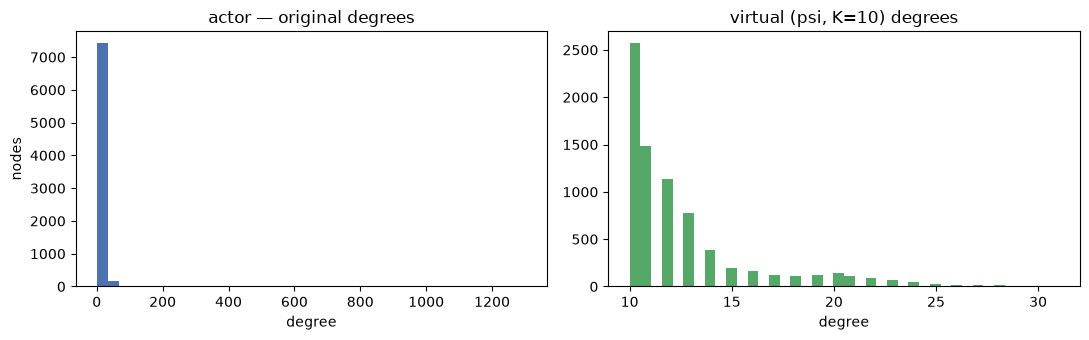

In [5]:
"""Plot the degree distribution of the original graph next to the virtual graph."""
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist([d for _, d in G.degree()], bins=40, color="#4C72B0")
ax[0].set_title(f"{DATASET} — original degrees"); ax[0].set_xlabel("degree"); ax[0].set_ylabel("nodes")
ax[1].hist([d for _, d in V.degree()], bins=40, color="#55A868")
ax[1].set_title(f"virtual (psi, K={K}) degrees"); ax[1].set_xlabel("degree")
plt.tight_layout(); plt.show()

## 4 · Check the rules (constraints)

Every virtual graph must obey the project's fairness and validity rules. The report below verifies them automatically.


In [6]:
"""Verify the construction rules on the built virtual graph."""
def constraint_report(base_graph, virtual, k):
    """Return a pass/fail table for the virtual-graph construction rules."""
    weights = [w for _, _, w in virtual.edges(data="weight")]
    degrees = [d for _, d in virtual.degree()]
    checks = {
        "same nodes (none missing)": set(virtual.nodes) == set(base_graph.nodes),
        "no self-loops":             nx.number_of_selfloops(virtual) == 0,
        "at least K per node":       min(degrees) >= k,
        "undirected (symmetric)":    not nx.is_directed(virtual),
        "weights all finite":        bool(np.all(np.isfinite(weights))),
        "weights in (0, 1]":         min(weights) > 0 and max(weights) <= 1,
    }
    return pd.DataFrame({"rule": list(checks), "pass": list(checks.values())})

constraint_report(G, V, K)

,rule,pass
0,same nodes (none missing),True
1,no self-loops,True
2,at least K per node,True
3,undirected (symmetric),True
4,weights all finite,True
5,"weights in (0, 1]",True


## 5 · Build every variant (the sweep)

To answer _which virtual graph is best_, all variants are built at the **same K** — same K keeps the comparison fair. Each is saved as its own edgelist under `output/notebook2_create_vir_graph/virtual_graphs/<dataset>/k<K>/<variant>/virtual_graph.edgelist`, ready for any encoder. K comes from the `KS` knob (Setup) — **`[10]`, the finalized K**.

**Graph-health table.** Every virtual graph built (or reused) automatically records one row — `dataset, sim, K, nodes, edges, avg_degree, components, isolates, path` — in **`results/graph_health.csv`**. It is one shared table that grows across datasets and keeps every K ever built (the displayed table therefore still shows the earlier K=5/20 rows). Use it later to check whether a bad score came from a broken graph (too sparse, disconnected, isolates, too dense), and as the ablation-quality table for the paper.


In [7]:
"""Build all (dataset x variant x K) virtual graphs; each one auto-records its row in the shared stats CSV."""
for DATASET in RUN_DATASETS:
    G = load_base_graph(DATASET)
    print(f"== {DATASET}: {G.number_of_nodes()} nodes / {G.number_of_edges()} edges", flush=True)
    for sim in SIMS:
        for k in KS:                           # full grid: every variant at every K (KS knob in Setup; original ignores K -> identical copies)
            build_virtual(G, sim, k, DATASET)

stats_df = pd.read_csv(STATS_CSV)          # the full table: accumulates every dataset x sim x K built so far
print("graph-health table ->", STATS_CSV)
display(stats_df[stats_df["dataset"].isin(RUN_DATASETS)].reset_index(drop=True))

== actor: 7600 nodes / 26659 edges


== amazon_photo: 7650 nodes / 119081 edges
== amazon_ratings: 24492 nodes / 93050 edges
== cora: 2708 nodes / 5278 edges
== pubmed: 19717 nodes / 44324 edges
== questions: 48921 nodes / 153540 edges
== roman_empire: 22662 nodes / 32927 edges
== squirrel_filtered: 2223 nodes / 46998 edges
== tolokers: 11758 nodes / 519000 edges
graph-health table -> results/graph_health.csv


,dataset,sim,K,nodes,edges,avg_degree,max_degree,components,isolates,path
0,actor,centrality,10,7600,44258,11.65,31,6,0,output/notebook2_create_vir_graph/virtual_grap...
1,actor,degree,10,7600,73589,19.37,33,34,0,output/notebook2_create_vir_graph/virtual_grap...
2,actor,hybrid,10,7600,73953,19.46,1312,1,0,output/notebook2_create_vir_graph/virtual_grap...
3,actor,hybrid_centrality,10,7600,70762,18.62,1306,1,0,output/notebook2_create_vir_graph/virtual_grap...
4,actor,hybrid_degree,10,7600,100072,26.33,1313,1,0,output/notebook2_create_vir_graph/virtual_grap...
...,...,...,...,...,...,...,...,...,...,...
58,tolokers,hybrid,10,11758,610509,103.85,2138,1,0,output/notebook2_create_vir_graph/virtual_grap...
59,tolokers,hybrid_centrality,10,11758,583005,99.17,2138,1,0,output/notebook2_create_vir_graph/virtual_grap...
60,tolokers,hybrid_degree,10,11758,619466,105.37,2138,1,0,output/notebook2_create_vir_graph/virtual_grap...
61,tolokers,original,10,11758,519000,88.28,2138,1,0,output/notebook2_create_vir_graph/virtual_grap...


## 6 · Toolbox — one fixed encoder

The central idea of Phase 2: **only the graph changes, never the encoder.** Every variant is embedded with the _same_ DeepWalk encoder and the _same_ settings, so any difference in score comes from the **virtual graph**, not the model. (Phase 3 swaps this bridge encoder for a GNN over the same edgelists.)

The three helpers below embed a graph, then score it on each task.


In [8]:
"""Fixed-encoder toolbox: embed a virtual graph, then score it on each task."""
LP_SPLITS = Path("splits") / "link_prediction" / "virtual_graph_study"   # shared with notebook 3 (fair encoder comparison)

def embed(virtual, task, sim, k, seed):
    """Embed a virtual graph with the fixed DeepWalk encoder; reuse the .emb file if already trained."""
    out = NB2 / task / DATASET / f"k{k}" / sim / f"deepwalk_s{seed}.emb"   # task folder first: node_classification | link_prediction
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.exists() and not FORCE_REBUILD:                  # reuse-or-create: skip if already embedded
        print(f"  reuse  seed {seed}  ->  {out.name}", flush=True)
        return out
    cost = sum(d * d for _, d in virtual.degree())          # node2vec precomputes 2nd-order tables -> runtime tracks sum(deg^2), NOT edge count
    print(f"  TRAIN  seed {seed}  |  {virtual.number_of_nodes()} nodes / {virtual.number_of_edges()} edges  |  cost {cost:.1e}"
          f"{'  <- SLOW: degree skew, check max_degree in graph_health.csv' if cost > 1e8 else ''}", flush=True)
    t0 = time.time()
    flat = tempfile.NamedTemporaryFile(suffix=".edgelist", delete=False).name
    nx.write_edgelist(virtual, flat, data=False)            # DeepWalk reads a plain (unweighted) edgelist
    DeepWalkModel().train(flat, str(out), seed=seed, params=I2V_PARAMS)
    os.unlink(flat)
    print(f"  done   seed {seed}  in {(time.time() - t0) / 60:.1f} min  ->  {out.name}", flush=True)
    return out

def node_class_f1(virtual, sim, k, seed):
    """Weighted-F1 node classification from a virtual graph's embedding."""
    emb = embed(virtual, "node_classification", sim, k, seed)
    f1s, _, _ = eval_nodeclass.evaluate(emb, DATASETS[DATASET]["labels"],
                                        train_frac=REPRO["nodeclass_train_frac"], seed=seed)
    return f1s["weighted"]

def link_pred_auc(sim, k, seed):
    """Link-prediction AUC: split 70/30, build the virtual graph from TRAIN edges only, embed, score held-out edges."""
    split_dir = LP_SPLITS / DATASET / f"seed_{seed}"
    if FORCE_REBUILD or not (split_dir / "test_pos.txt").exists():   # reuse the split if present (same split per seed -> fair, no leakage)
        print(f"  split  seed {seed}  70/30 edges ...", flush=True)
        prepare_linkpred.prepare(DATASETS[DATASET]["edgelist"], split_dir,
                                 test_frac=REPRO["linkpred_test_frac"], seed=seed)
    emb = NB2 / "link_prediction" / DATASET / f"k{k}" / sim / f"deepwalk_s{seed}.emb"
    if FORCE_REBUILD or not emb.exists():                            # reuse the embedding if present; else build train-virtual + embed
        print(f"  build  seed {seed}  virtual graph from train edges only ...", flush=True)
        train_graph = graph_io.load_graph(split_dir / "train.edgelist")
        Vtr = VirtualGraph(train_graph, seed=REPRO["seed"]).build(sim, k)   # built on train edges only
        emb = embed(Vtr, "link_prediction", sim, k, seed)
    else:
        print(f"  reuse  seed {seed}  ->  {emb.name}", flush=True)
    return eval_linkpred.evaluate(str(emb), str(split_dir), seed=seed, score=REPRO["linkpred_score"])

## 7 · Compare variants — Node classification (weighted F1)

Each variant is embedded and scored across seeds; the mean ± std shows which virtual graph classifies nodes best at K.

_Note:_ structural embeddings describe **roles**, not communities, so absolute F1 on community-labelled Cora is modest — the **comparison across variants** is what matters here.



[actor 1/7] node classification | psi K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  F1 0.2023 +/- 0.0025

[actor 2/7] node classification | degree K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  F1 0.1831 +/- 0.0088

[actor 3/7] node classification | centrality K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  F1 0.1970 +/- 0.0024

[actor 4/7] node classification | original K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  F1 0.2075 +/- 0.0119

[actor 5/7] node classification | hybrid K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  F1 0.2026 +/- 0.0062

[actor 6/7]

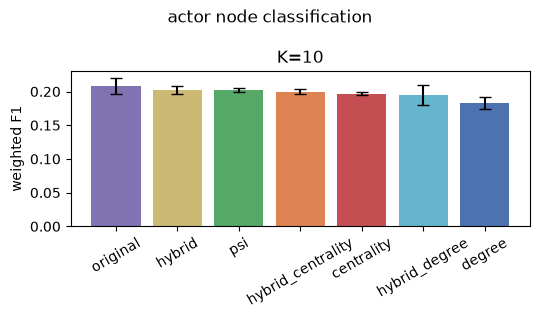

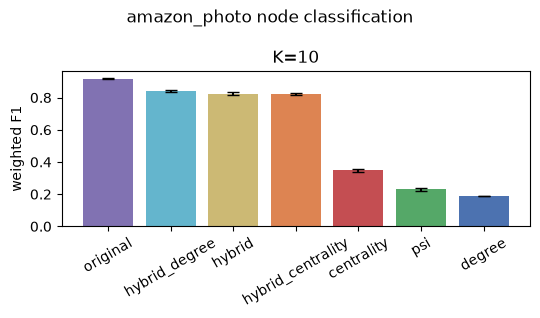

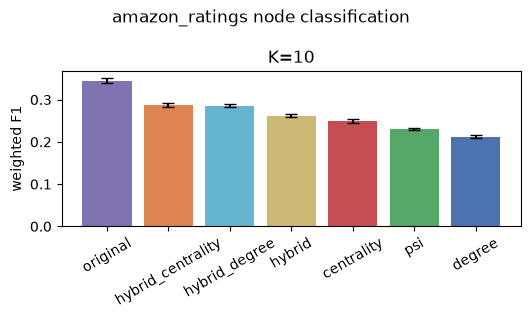

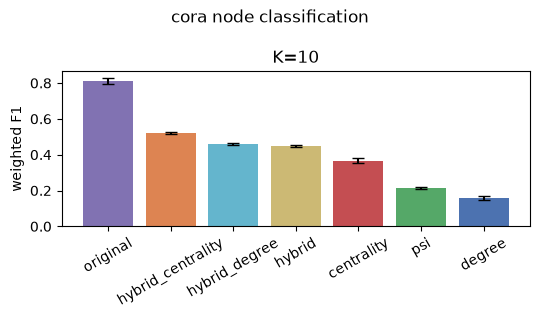

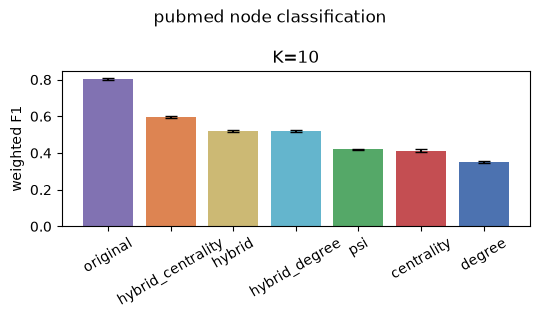

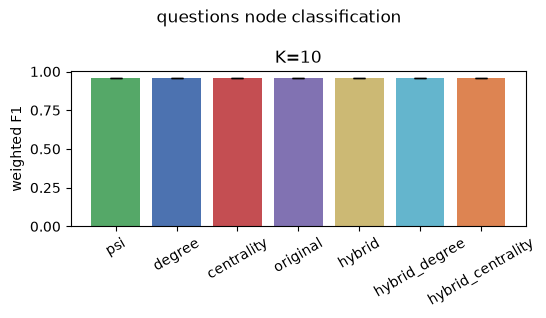

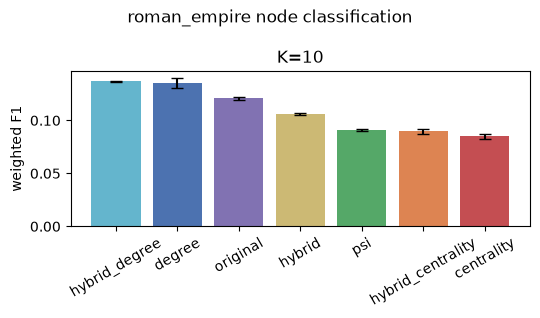

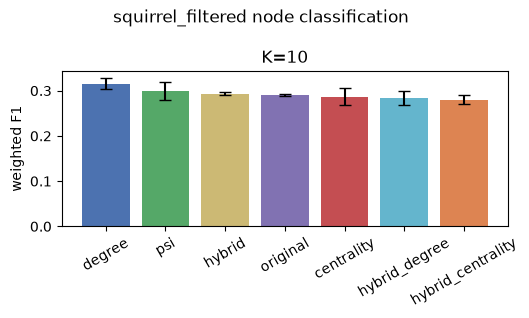

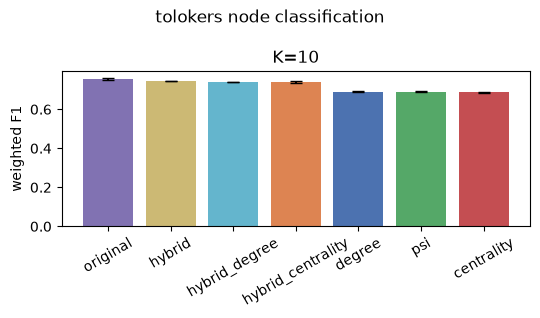

,dataset,variant,K,F1_mean,F1_std
0,actor,original,10,0.207524,0.011910
1,actor,hybrid,10,0.202573,0.006219
2,actor,psi,10,0.202253,0.002477
3,actor,hybrid_centrality,10,0.199908,0.003644
4,actor,centrality,10,0.197031,0.002439
...,...,...,...,...,...
58,tolokers,hybrid_degree,10,0.740061,0.000786
59,tolokers,hybrid_centrality,10,0.739117,0.004608
60,tolokers,degree,10,0.690651,0.002290
61,tolokers,psi,10,0.689716,0.002195


In [9]:
"""Node-classification comparison across datasets x variants x K (mean +/- std over seeds). Skipped where a dataset has no labels."""
nc_rows = []
for DATASET in RUN_DATASETS:                       # rebinds the global DATASET -> embed()/node_class_f1() pick it up
    if DATASETS[DATASET]["labels"] is None:
        print(f"{DATASET} has no labels -> node classification skipped (link prediction still runs).")
        continue
    G = load_base_graph(DATASET)
    for i, (sim, k) in enumerate([(s, k) for s in SIMS for k in KS], 1):
        print(f"\n[{DATASET} {i}/{len(SIMS) * len(KS)}] node classification | {sim} K={k} | {len(SEEDS)} seeds", flush=True)
        Vk, _ = build_virtual(G, sim, k, DATASET)
        scores = [node_class_f1(Vk, sim, k, s) for s in SEEDS]
        print(f"  F1 {np.mean(scores):.4f} +/- {np.std(scores):.4f}", flush=True)
        nc_rows.append({"dataset": DATASET, "variant": sim, "K": k, "F1_mean": np.mean(scores), "F1_std": np.std(scores)})
nc = pd.DataFrame(nc_rows).sort_values(["dataset", "K", "F1_mean"], ascending=[True, True, False]).reset_index(drop=True)
for ds in nc["dataset"].unique():                  # one figure per dataset, one panel per K
    d0 = nc[nc["dataset"] == ds]
    fig, axes = plt.subplots(1, len(KS), figsize=(5.5 * len(KS), 3.2), sharey=True)
    for ax, k in zip(np.atleast_1d(axes), KS):
        d = d0[d0["K"] == k]
        ax.bar(d["variant"], d["F1_mean"], yerr=d["F1_std"], capsize=4, color=[PALETTE[v] for v in d["variant"]])
        ax.set_title(f"K={k}"); ax.tick_params(axis="x", rotation=30)
    np.atleast_1d(axes)[0].set_ylabel("weighted F1")
    plt.suptitle(f"{ds} node classification"); plt.tight_layout(); plt.show()
nc

## 8 · Compare variants — Link prediction (AUC)

Link prediction retrains on a 70% edge split and scores held-out edges. The virtual graph is rebuilt from **train edges only**, so no test edge leaks into the embedding.



[actor 1/7] link prediction | psi K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  AUC 0.5034 +/- 0.0050

[actor 2/7] link prediction | degree K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  AUC 0.6152 +/- 0.0024

[actor 3/7] link prediction | centrality K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  AUC 0.5041 +/- 0.0060

[actor 4/7] link prediction | original K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  AUC 0.7016 +/- 0.0035

[actor 5/7] link prediction | hybrid K=10 | 3 seeds
  reuse  seed 42  ->  deepwalk_s42.emb
  reuse  seed 43  ->  deepwalk_s43.emb
  reuse  seed 44  ->  deepwalk_s44.emb
  AUC 0.6329 +/- 0.0038

[actor 6/7] link predictio

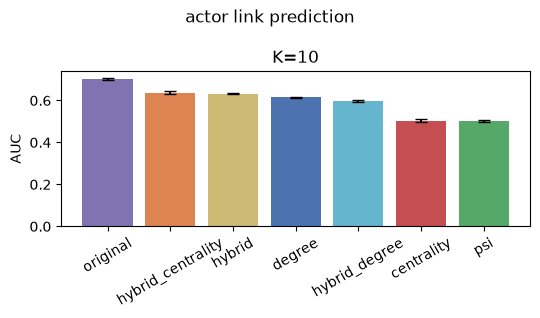

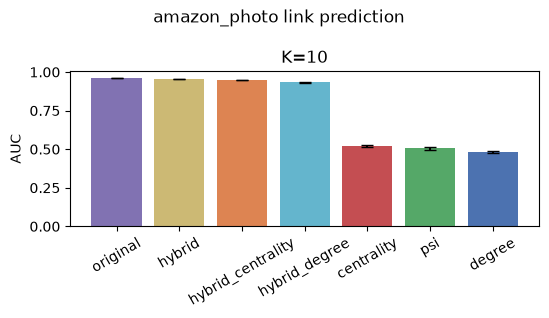

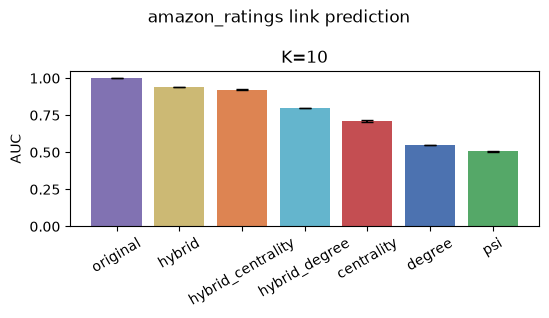

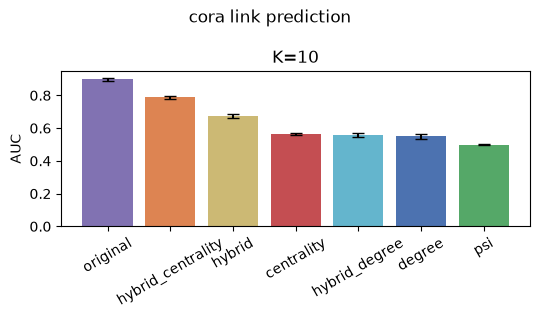

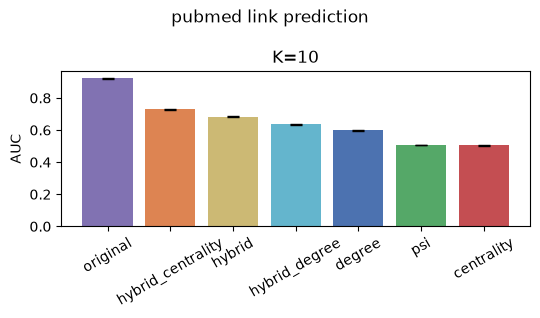

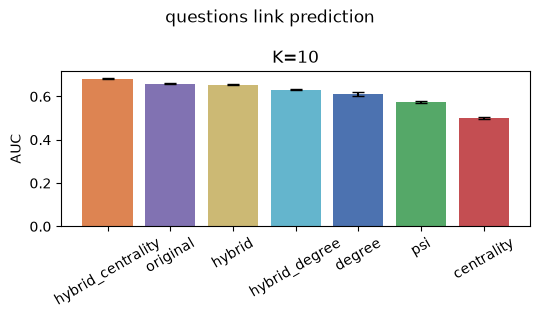

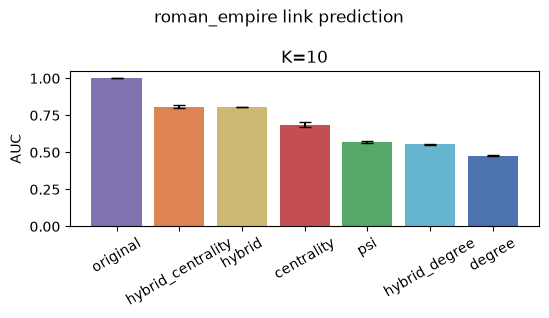

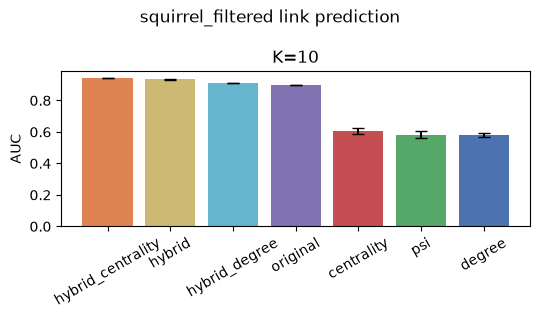

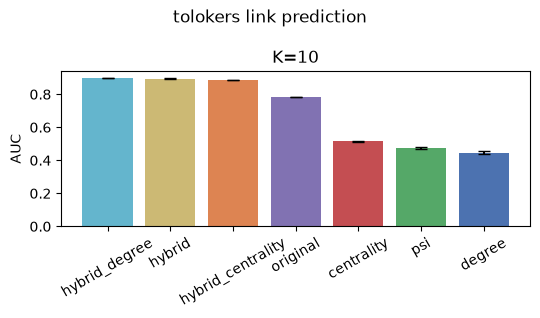

,dataset,variant,K,AUC_mean,AUC_std
0,actor,original,10,0.701570,0.003550
1,actor,hybrid_centrality,10,0.636766,0.007436
2,actor,hybrid,10,0.632906,0.003777
3,actor,degree,10,0.615186,0.002443
4,actor,hybrid_degree,10,0.599577,0.004637
...,...,...,...,...,...
58,tolokers,hybrid_centrality,10,0.883731,0.000338
59,tolokers,original,10,0.785896,0.000267
60,tolokers,centrality,10,0.514190,0.002286
61,tolokers,psi,10,0.475084,0.004080


In [10]:
"""Link-prediction comparison across datasets x variants x K (mean +/- std over seeds)."""
lp_rows = []
for DATASET in RUN_DATASETS:                       # rebinds the global DATASET -> link_pred_auc() picks it up
    for i, (sim, k) in enumerate([(s, k) for s in SIMS for k in KS], 1):
        print(f"\n[{DATASET} {i}/{len(SIMS) * len(KS)}] link prediction | {sim} K={k} | {len(SEEDS)} seeds", flush=True)
        scores = [link_pred_auc(sim, k, s) for s in SEEDS]
        print(f"  AUC {np.mean(scores):.4f} +/- {np.std(scores):.4f}", flush=True)
        lp_rows.append({"dataset": DATASET, "variant": sim, "K": k, "AUC_mean": np.mean(scores), "AUC_std": np.std(scores)})
lp = pd.DataFrame(lp_rows).sort_values(["dataset", "K", "AUC_mean"], ascending=[True, True, False]).reset_index(drop=True)

for ds in lp["dataset"].unique():                  # one figure per dataset, one panel per K
    d0 = lp[lp["dataset"] == ds]
    fig, axes = plt.subplots(1, len(KS), figsize=(5.5 * len(KS), 3.2), sharey=True)
    for ax, k in zip(np.atleast_1d(axes), KS):
        d = d0[d0["K"] == k]
        ax.bar(d["variant"], d["AUC_mean"], yerr=d["AUC_std"], capsize=4, color=[PALETTE[v] for v in d["variant"]])
        ax.set_title(f"K={k}"); ax.tick_params(axis="x", rotation=30)
    np.atleast_1d(axes)[0].set_ylabel("AUC")
    plt.suptitle(f"{ds} link prediction"); plt.tight_layout(); plt.show()
lp

## 9 · Results summary + save

Merge both tasks into one table and save it under `results/snapshots/` (per-run comparison CSVs; the accumulating master table is `results/scoreboard.csv`, filled by notebook 3).


In [11]:
"""Merge task results and save one Phase-2 comparison table per dataset (one row per variant x K)."""
summary = nc.merge(lp, on=["dataset", "variant", "K"], how="outer").sort_values(["dataset", "K", "variant"]).reset_index(drop=True)
out = Path("results") / "snapshots"; out.mkdir(parents=True, exist_ok=True)
for ds, d in summary.groupby("dataset"):
    csv = out / f"{ds}_variant_comparison_K{'-'.join(str(k) for k in KS)}.csv"
    d.drop(columns="dataset").to_csv(csv, index=False)
    print("saved ->", csv)
summary

saved -> results/snapshots/actor_variant_comparison_K10.csv
saved -> results/snapshots/amazon_photo_variant_comparison_K10.csv
saved -> results/snapshots/amazon_ratings_variant_comparison_K10.csv
saved -> results/snapshots/cora_variant_comparison_K10.csv
saved -> results/snapshots/pubmed_variant_comparison_K10.csv
saved -> results/snapshots/questions_variant_comparison_K10.csv
saved -> results/snapshots/roman_empire_variant_comparison_K10.csv
saved -> results/snapshots/squirrel_filtered_variant_comparison_K10.csv
saved -> results/snapshots/tolokers_variant_comparison_K10.csv


,dataset,variant,K,F1_mean,F1_std,AUC_mean,AUC_std
0,actor,centrality,10,0.197031,0.002439,0.504139,0.006038
1,actor,degree,10,0.183110,0.008774,0.615186,0.002443
2,actor,hybrid,10,0.202573,0.006219,0.632906,0.003777
3,actor,hybrid_centrality,10,0.199908,0.003644,0.636766,0.007436
4,actor,hybrid_degree,10,0.194850,0.014481,0.599577,0.004637
...,...,...,...,...,...,...,...
58,tolokers,hybrid,10,0.744312,0.001849,0.895354,0.000461
59,tolokers,hybrid_centrality,10,0.739117,0.004608,0.883731,0.000338
60,tolokers,hybrid_degree,10,0.740061,0.000786,0.895911,0.000185
61,tolokers,original,10,0.754286,0.004021,0.785896,0.000267
